## Objective:
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset. 


### Exploratory Data Analysis (EDA):

1.	Load the Titanic dataset using Python's pandas library.

2.	Check for missing values.

3.	Explore data distributions using histograms and box plots.

4.	Visualize relationships between features and survival using scatter plots and bar plots.


In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("="*80)
print("DIABETES PREDICTION: LIGHTGBM VS XGBOOST COMPARISON")
print("="*80)

DIABETES PREDICTION: LIGHTGBM VS XGBOOST COMPARISON


In [22]:
# ============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# 1. Load the dataset
print("\n1. LOADING DATASET")
print("-" * 50)
df = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

print(f"\nStatistical summary:")
print(df.describe())


1. LOADING DATASET
--------------------------------------------------
Dataset shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------        

In [23]:
# 2. Check for missing values
print("\n2. CHECKING FOR MISSING VALUES")
print("-" * 50)

# Check for null values
print(f"Missing values in each column:")
print(df.isnull().sum())

# Check for zero values that might indicate missing data (common in medical datasets)
print(f"\nZero values in each column (may indicate missing data):")
for column in df.columns:
    if column != 'Outcome':  # Outcome is binary (0/1), so zeros are valid
        zero_count = (df[column] == 0).sum()
        print(f"{column}: {zero_count} zeros ({zero_count/len(df)*100:.2f}%)")

# Note: In diabetes dataset, zeros in Glucose, BloodPressure, etc. are often missing values
# We'll handle these in preprocessing


2. CHECKING FOR MISSING VALUES
--------------------------------------------------
Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values in each column (may indicate missing data):
Pregnancies: 111 zeros (14.45%)
Glucose: 5 zeros (0.65%)
BloodPressure: 35 zeros (4.56%)
SkinThickness: 227 zeros (29.56%)
Insulin: 374 zeros (48.70%)
BMI: 11 zeros (1.43%)
DiabetesPedigreeFunction: 0 zeros (0.00%)
Age: 0 zeros (0.00%)



3. DATA DISTRIBUTIONS
--------------------------------------------------


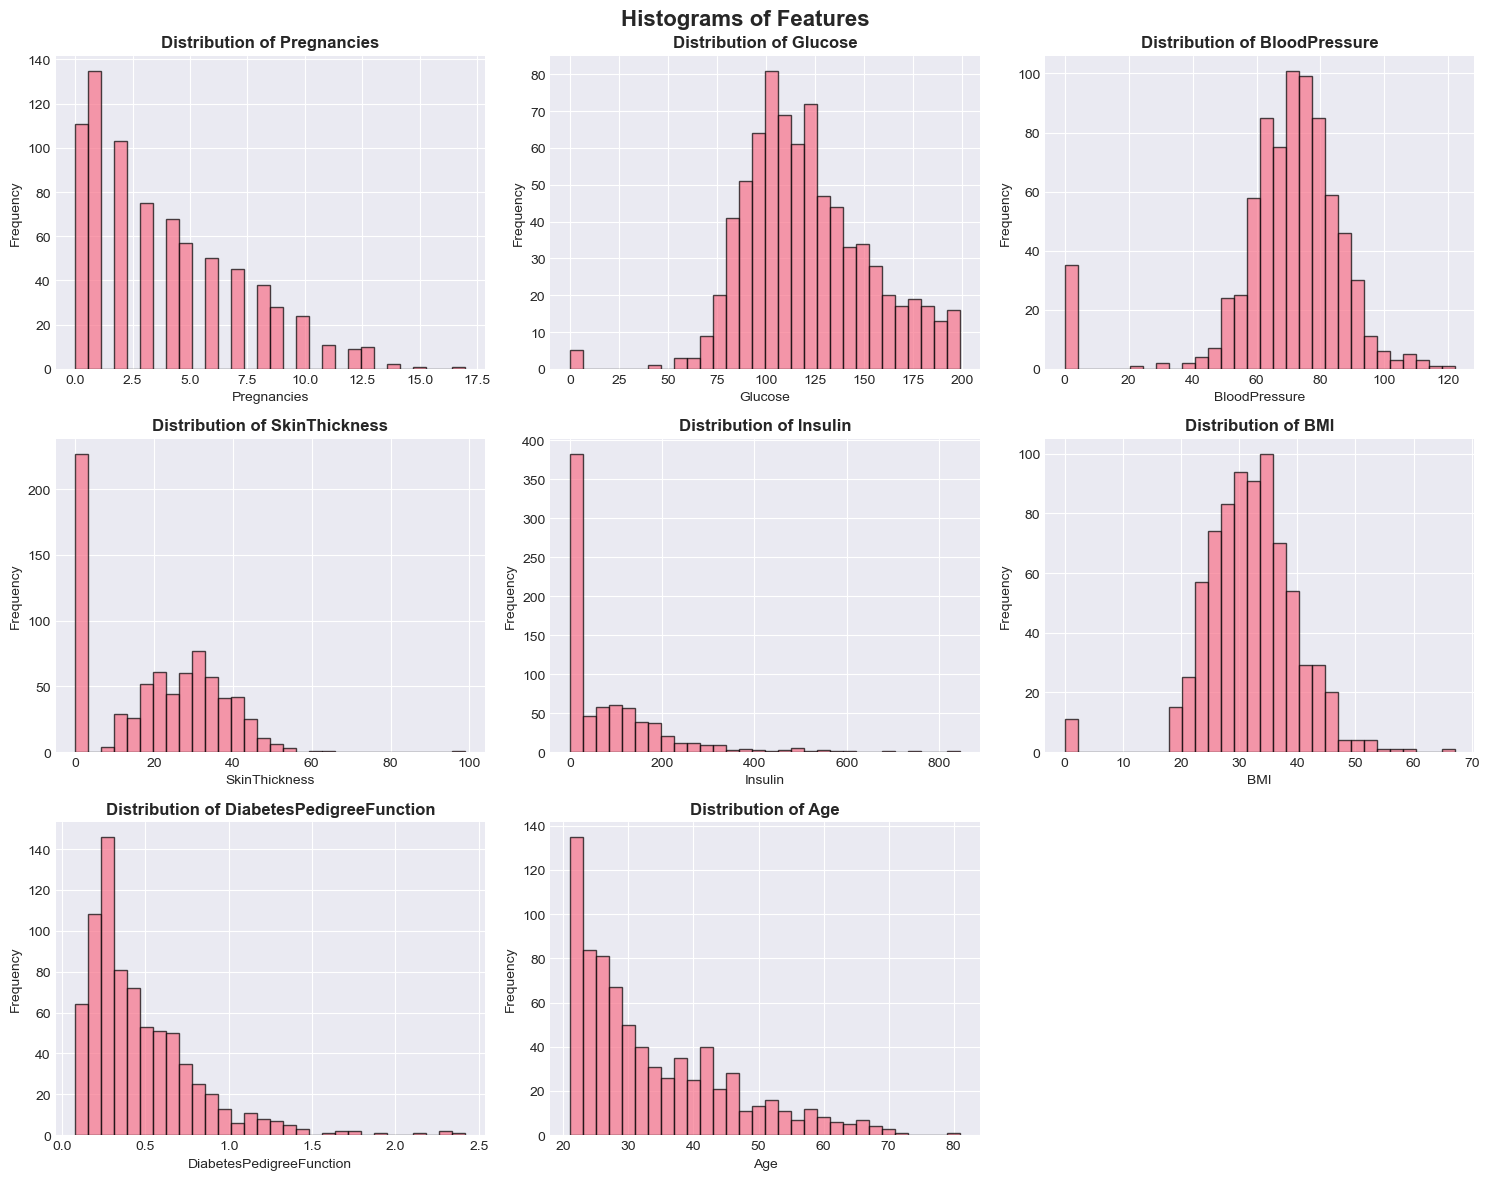

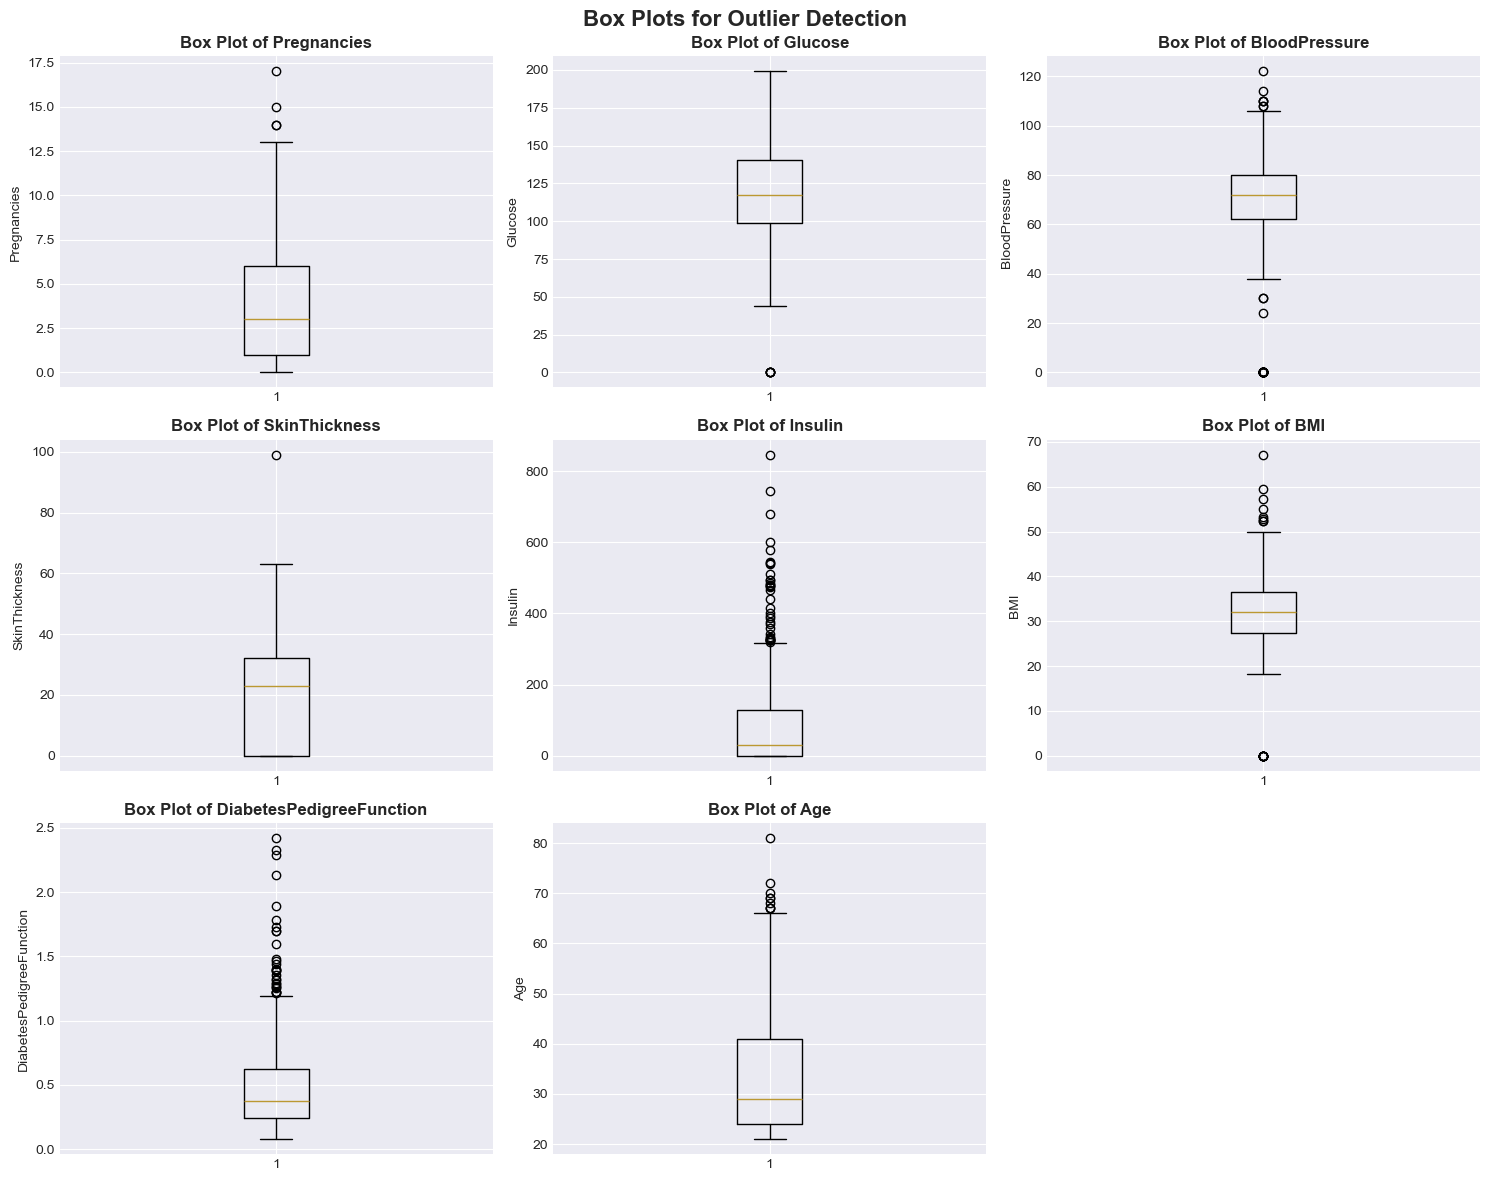

In [24]:
# 3. Explore data distributions using histograms and box plots
print("\n3. DATA DISTRIBUTIONS")
print("-" * 50)

# Create figure for histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    
# Hide the last subplot
axes[8].axis('off')
plt.suptitle('Histograms of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Box plots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(features):
    axes[idx].boxplot(df[feature])
    axes[idx].set_title(f'Box Plot of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature)
    
axes[8].axis('off')
plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


4. RELATIONSHIPS BETWEEN FEATURES AND OUTCOME
--------------------------------------------------


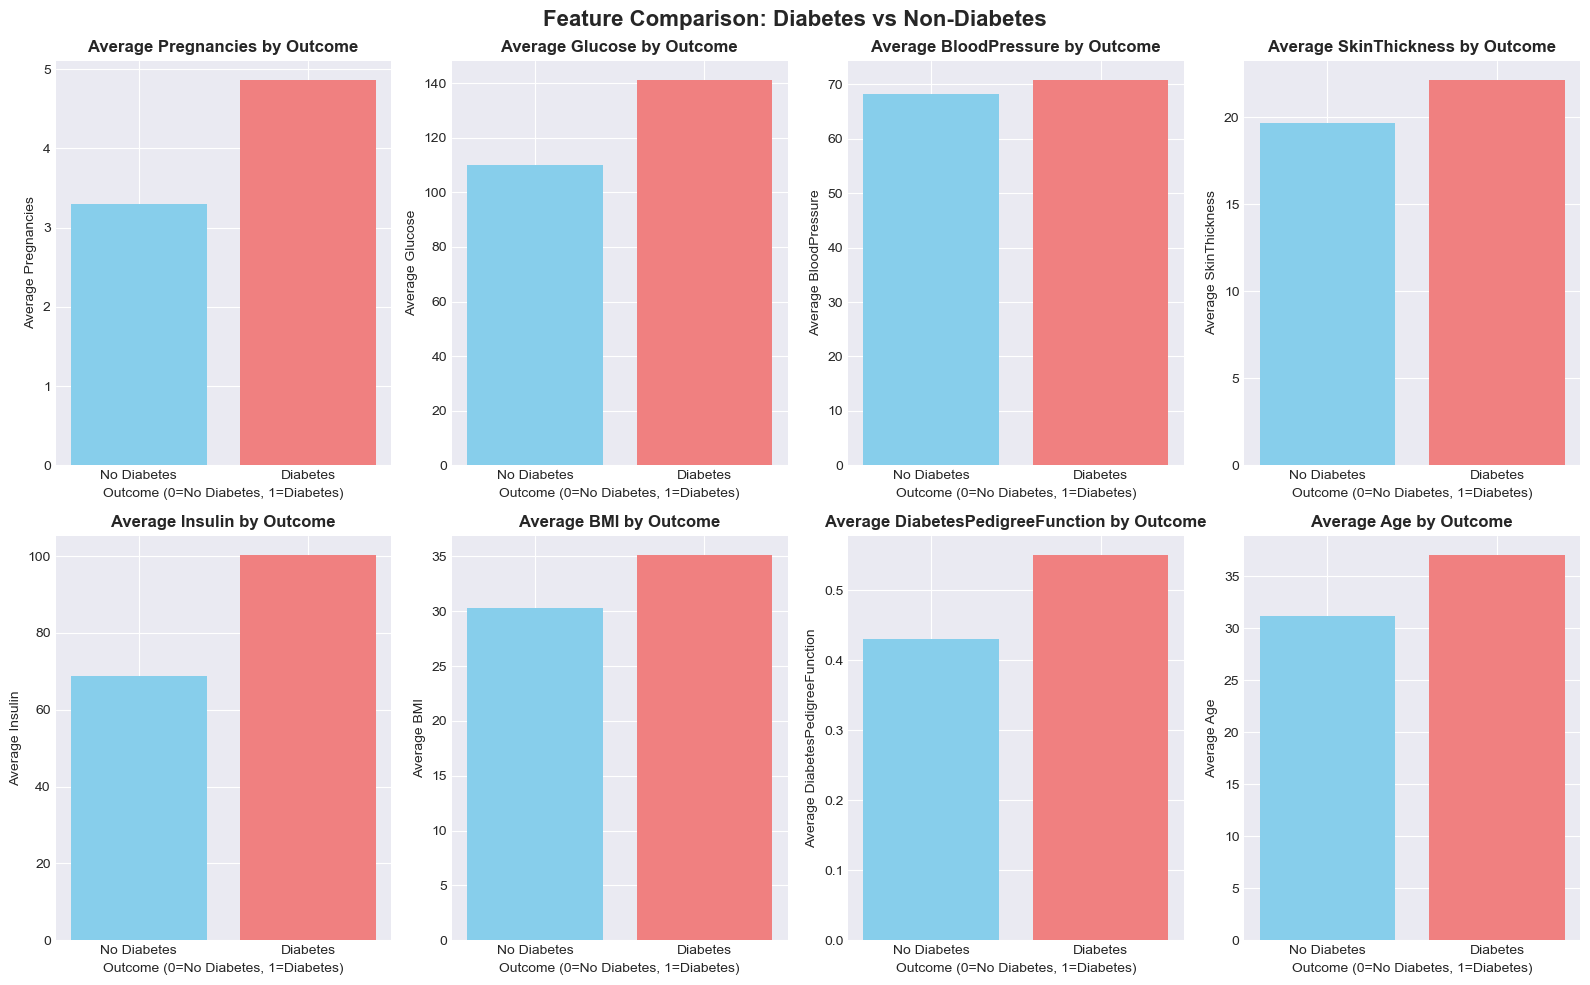

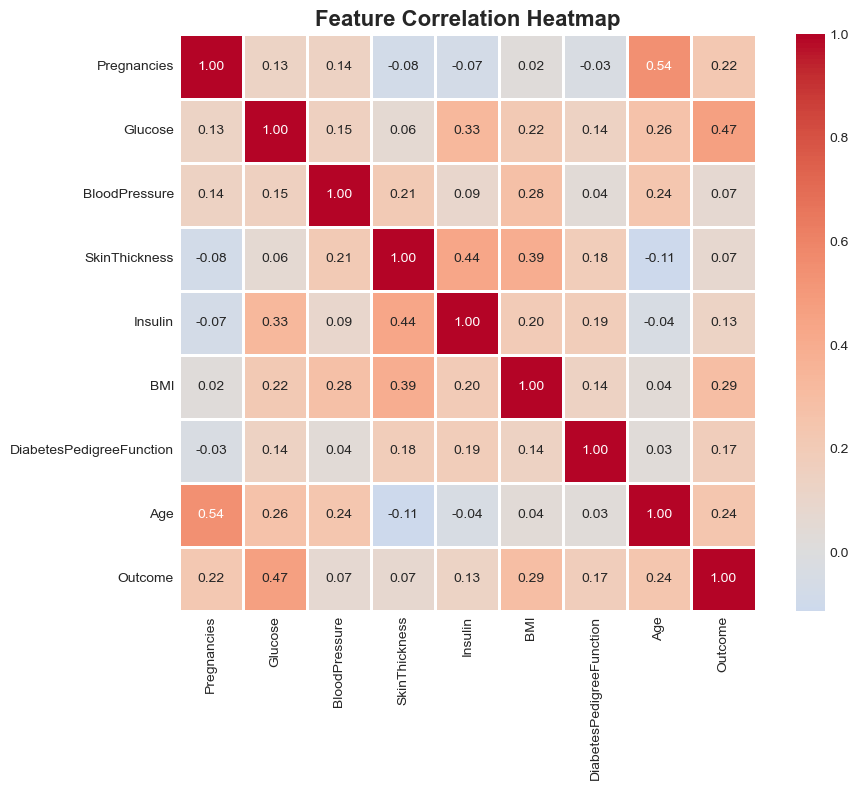


Correlation with Outcome (target variable):
Outcome: 1.000
Glucose: 0.467
BMI: 0.293
Age: 0.238
Pregnancies: 0.222
DiabetesPedigreeFunction: 0.174
Insulin: 0.131
SkinThickness: 0.075
BloodPressure: 0.065


In [25]:
# 4. Visualize relationships between features and outcome
print("\n4. RELATIONSHIPS BETWEEN FEATURES AND OUTCOME")
print("-" * 50)

# Bar plots for feature comparison by outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    # Create DataFrame for plotting
    plot_data = df.groupby('Outcome')[feature].mean().reset_index()
    axes[idx].bar(plot_data['Outcome'], plot_data[feature], color=['skyblue', 'lightcoral'])
    axes[idx].set_title(f'Average {feature} by Outcome', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
    axes[idx].set_ylabel(f'Average {feature}')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.suptitle('Feature Comparison: Diabetes vs Non-Diabetes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation with outcome
print("\nCorrelation with Outcome (target variable):")
correlations = df.corr()['Outcome'].sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.3f}")

### Data Preprocessing:

1.	Impute missing values.

2.	Encode categorical variables using one-hot encoding or label encoding. 

3.	If needed you can apply more preprocessing methods on the given dataset


In [26]:
# ============================================
# DATA PREPROCESSING
# ============================================

print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Create a copy of the dataset for preprocessing
df_processed = df.copy()

# 1. Handle missing values (zeros that likely represent missing data)
print("\n1. HANDLING MISSING VALUES")
print("-" * 50)

# For medical measurements, zero values are often impossible or missing
# We'll replace zeros with NaN for these columns
columns_with_possible_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in columns_with_possible_missing:
    missing_count = (df_processed[column] == 0).sum()
    print(f"Replacing {missing_count} zeros in {column} with NaN")
    df_processed[column] = df_processed[column].replace(0, np.nan)

# Impute missing values with median (robust to outliers)
print("\nImputing missing values with median...")
for column in columns_with_possible_missing:
    median_value = df_processed[column].median()
    df_processed[column].fillna(median_value, inplace=True)
    print(f"{column}: imputed with median = {median_value:.2f}")

# Verify no missing values remain
print(f"\nMissing values after imputation: {df_processed.isnull().sum().sum()}")

# 2. Feature Engineering (optional preprocessing)
print("\n2. FEATURE ENGINEERING")
print("-" * 50)

# Create age groups
df_processed['AgeGroup'] = pd.cut(df_processed['Age'], 
                                   bins=[0, 30, 40, 50, 60, 100], 
                                   labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Create BMI categories
df_processed['BMICategory'] = pd.cut(df_processed['BMI'], 
                                      bins=[0, 18.5, 25, 30, 100], 
                                      labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Create Glucose categories
df_processed['GlucoseCategory'] = pd.cut(df_processed['Glucose'], 
                                          bins=[0, 70, 100, 126, 200], 
                                          labels=['Low', 'Normal', 'Prediabetes', 'Diabetes'])

print("Created new features: AgeGroup, BMICategory, GlucoseCategory")

# 3. Encode categorical variables
print("\n3. ENCODING CATEGORICAL VARIABLES")
print("-" * 50)

# One-hot encoding for categorical features
categorical_features = ['AgeGroup', 'BMICategory', 'GlucoseCategory']
df_encoded = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

print(f"Original features: {df.shape[1]}")
print(f"Features after encoding: {df_encoded.shape[1]}")

# 4. Feature scaling
print("\n4. FEATURE SCALING")
print("-" * 50)

# Separate features and target
X = df_encoded.drop('Outcome', axis=1)
y = df_encoded['Outcome']

# Scale numerical features (important for some algorithms)
scaler = StandardScaler()
numerical_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                      'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Features scaled using StandardScaler")
print(f"Final feature set shape: {X.shape}")
print(f"Features: {list(X.columns)}")


DATA PREPROCESSING

1. HANDLING MISSING VALUES
--------------------------------------------------
Replacing 5 zeros in Glucose with NaN
Replacing 35 zeros in BloodPressure with NaN
Replacing 227 zeros in SkinThickness with NaN
Replacing 374 zeros in Insulin with NaN
Replacing 11 zeros in BMI with NaN

Imputing missing values with median...
Glucose: imputed with median = 117.00
BloodPressure: imputed with median = 72.00
SkinThickness: imputed with median = 29.00
Insulin: imputed with median = 125.00
BMI: imputed with median = 32.30

Missing values after imputation: 0

2. FEATURE ENGINEERING
--------------------------------------------------
Created new features: AgeGroup, BMICategory, GlucoseCategory

3. ENCODING CATEGORICAL VARIABLES
--------------------------------------------------
Original features: 9
Features after encoding: 19

4. FEATURE SCALING
--------------------------------------------------
Features scaled using StandardScaler
Final feature set shape: (768, 18)
Features: ['

### Building Predictive Models:

1.	Split the preprocessed dataset into training and testing sets.

2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

3.	Build predictive models using LightGBM and XGBoost algorithms.

4.	Train the models on the training set and evaluate their performance on the testing set.

5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.


In [27]:
# ============================================
# BUILDING PREDICTIVE MODELS
# ============================================

print("\n" + "="*80)
print("BUILDING PREDICTIVE MODELS")
print("="*80)

# 1. Split the dataset into training and testing sets
print("\n1. TRAIN-TEST SPLIT")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training set - Diabetes: {y_train.sum()}, Non-Diabetes: {len(y_train)-y_train.sum()}")
print(f"Testing set - Diabetes: {y_test.sum()}, Non-Diabetes: {len(y_test)-y_test.sum()}")

# 2. Define evaluation metrics
print("\n2. EVALUATION METRICS")
print("-" * 50)
print("Metrics to be used:")
print("- Accuracy: Overall correctness of predictions")
print("- Precision: Accuracy of positive predictions")
print("- Recall: Ability to find all positive samples")
print("- F1-Score: Harmonic mean of precision and recall")
print("- AUC-ROC: Model's ability to distinguish between classes")

# Function to evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model performance using multiple metrics
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Cross-validation Accuracy (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'fpr': fpr,
        'tpr': tpr
    }

# 3. Build LightGBM model (with hyperparameter tuning)
print("\n3. BUILDING LIGHTGBM MODEL")
print("-" * 50)

# Initial LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)

# Hyperparameter tuning for LightGBM
print("Performing hyperparameter tuning for LightGBM...")
lgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70]
}

lgb_grid_search = GridSearchCV(
    lgb_model, 
    lgb_param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

lgb_grid_search.fit(X_train, y_train)

print(f"Best LightGBM parameters: {lgb_grid_search.best_params_}")
print(f"Best cross-validation score: {lgb_grid_search.best_score_:.4f}")

# Best LightGBM model
best_lgb = lgb_grid_search.best_estimator_

# 4. Build XGBoost model (with hyperparameter tuning)
print("\n4. BUILDING XGBOOST MODEL")
print("-" * 50)

# Initial XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Hyperparameter tuning for XGBoost
print("Performing hyperparameter tuning for XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    xgb_model, 
    xgb_param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

xgb_grid_search.fit(X_train, y_train)

print(f"Best XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Best cross-validation score: {xgb_grid_search.best_score_:.4f}")

# Best XGBoost model
best_xgb = xgb_grid_search.best_estimator_

# 5. Train models and evaluate
print("\n5. MODEL EVALUATION ON TEST SET")
print("-" * 50)

# Evaluate LightGBM
lgb_results = evaluate_model(best_lgb, X_test, y_test, "LightGBM")

# Evaluate XGBoost
xgb_results = evaluate_model(best_xgb, X_test, y_test, "XGBoost")


BUILDING PREDICTIVE MODELS

1. TRAIN-TEST SPLIT
--------------------------------------------------
Training set size: (614, 18)
Testing set size: (154, 18)
Training set - Diabetes: 214, Non-Diabetes: 400
Testing set - Diabetes: 54, Non-Diabetes: 100

2. EVALUATION METRICS
--------------------------------------------------
Metrics to be used:
- Accuracy: Overall correctness of predictions
- Precision: Accuracy of positive predictions
- Recall: Ability to find all positive samples
- F1-Score: Harmonic mean of precision and recall
- AUC-ROC: Model's ability to distinguish between classes

3. BUILDING LIGHTGBM MODEL
--------------------------------------------------
Performing hyperparameter tuning for LightGBM...
Best LightGBM parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}
Best cross-validation score: 0.7688

4. BUILDING XGBOOST MODEL
--------------------------------------------------
Performing hyperparameter tuning for XGBoost...
Best XGBoost


COMPARATIVE ANALYSIS

1. PERFORMANCE METRICS COMPARISON
--------------------------------------------------
   Metric  LightGBM  XGBoost
 Accuracy  0.759740 0.753247
Precision  0.688889 0.673913
   Recall  0.574074 0.574074
 F1-Score  0.626263 0.620000
  AUC-ROC  0.828519 0.825000
  CV Mean  0.768772 0.763894


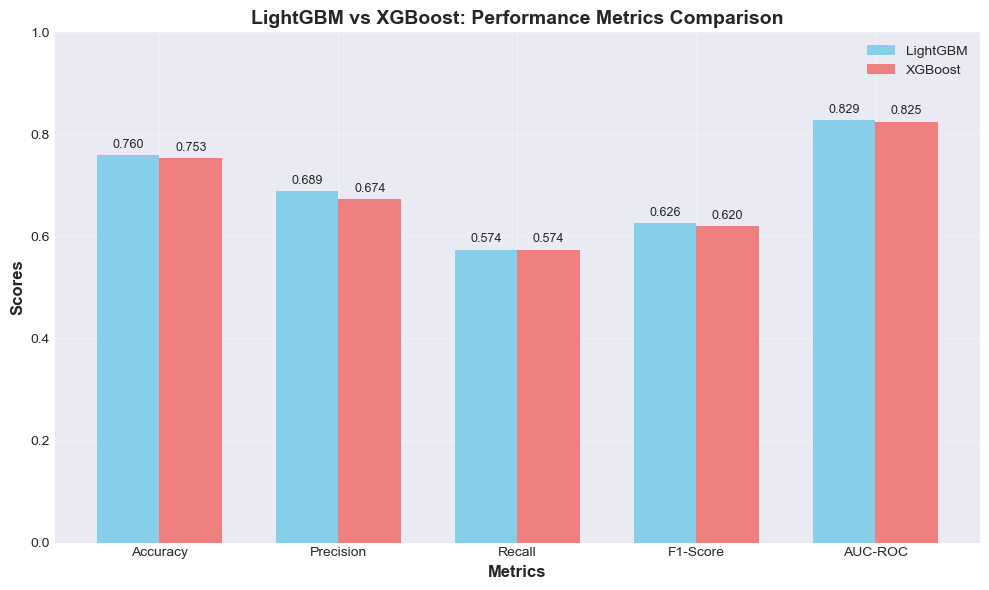

In [28]:
# ============================================
# COMPARATIVE ANALYSIS
# ============================================

print("\n" + "="*80)
print("COMPARATIVE ANALYSIS")
print("="*80)

# 1. Compare performance metrics
print("\n1. PERFORMANCE METRICS COMPARISON")
print("-" * 50)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'CV Mean'],
    'LightGBM': [lgb_results['accuracy'], lgb_results['precision'], 
                 lgb_results['recall'], lgb_results['f1'], 
                 lgb_results['auc_roc'], lgb_results['cv_mean']],
    'XGBoost': [xgb_results['accuracy'], xgb_results['precision'], 
                xgb_results['recall'], xgb_results['f1'], 
                xgb_results['auc_roc'], xgb_results['cv_mean']]
})

print(comparison_df.to_string(index=False))

# 2. Visualization of metrics comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.35

lgb_scores = [lgb_results['accuracy'], lgb_results['precision'], 
              lgb_results['recall'], lgb_results['f1'], lgb_results['auc_roc']]
xgb_scores = [xgb_results['accuracy'], xgb_results['precision'], 
              xgb_results['recall'], xgb_results['f1'], xgb_results['auc_roc']]

bars1 = ax.bar(x - width/2, lgb_scores, width, label='LightGBM', color='skyblue')
bars2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost', color='lightcoral')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('LightGBM vs XGBoost: Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


3. CONFUSION MATRICES
--------------------------------------------------


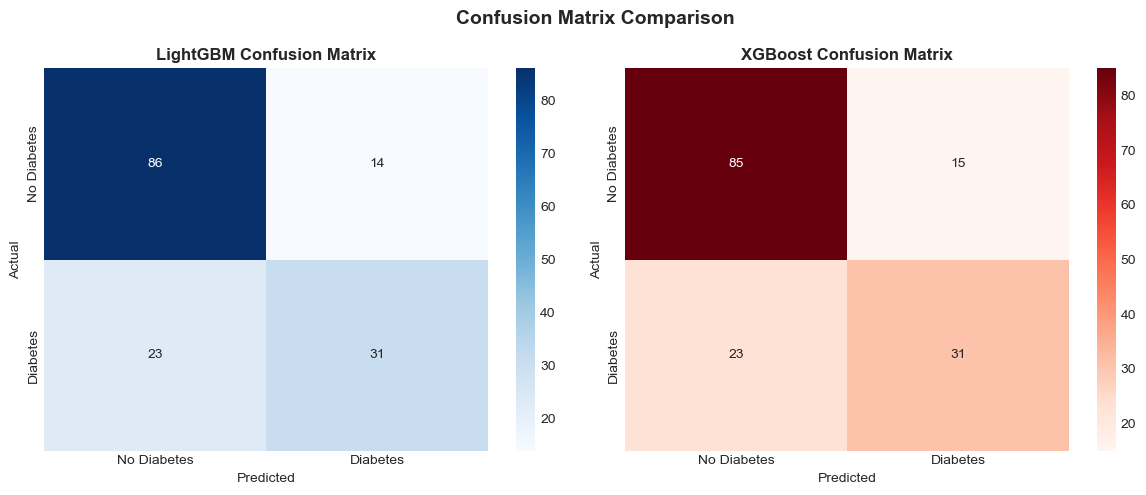

LightGBM - True Negatives: 86, False Positives: 14, False Negatives: 23, True Positives: 31
XGBoost - True Negatives: 85, False Positives: 15, False Negatives: 23, True Positives: 31


In [29]:
# 3. Confusion matrices comparison
print("\n3. CONFUSION MATRICES")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LightGBM confusion matrix
cm_lgb = confusion_matrix(y_test, lgb_results['y_pred'])
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('LightGBM Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('Actual', fontsize=10)
axes[0].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[0].set_yticklabels(['No Diabetes', 'Diabetes'])

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_results['y_pred'])
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('Actual', fontsize=10)
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[1].set_yticklabels(['No Diabetes', 'Diabetes'])

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate and display misclassifications
tn_lgb, fp_lgb, fn_lgb, tp_lgb = cm_lgb.ravel()
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

print(f"LightGBM - True Negatives: {tn_lgb}, False Positives: {fp_lgb}, False Negatives: {fn_lgb}, True Positives: {tp_lgb}")
print(f"XGBoost - True Negatives: {tn_xgb}, False Positives: {fp_xgb}, False Negatives: {fn_xgb}, True Positives: {tp_xgb}")


4. ROC CURVES COMPARISON
--------------------------------------------------


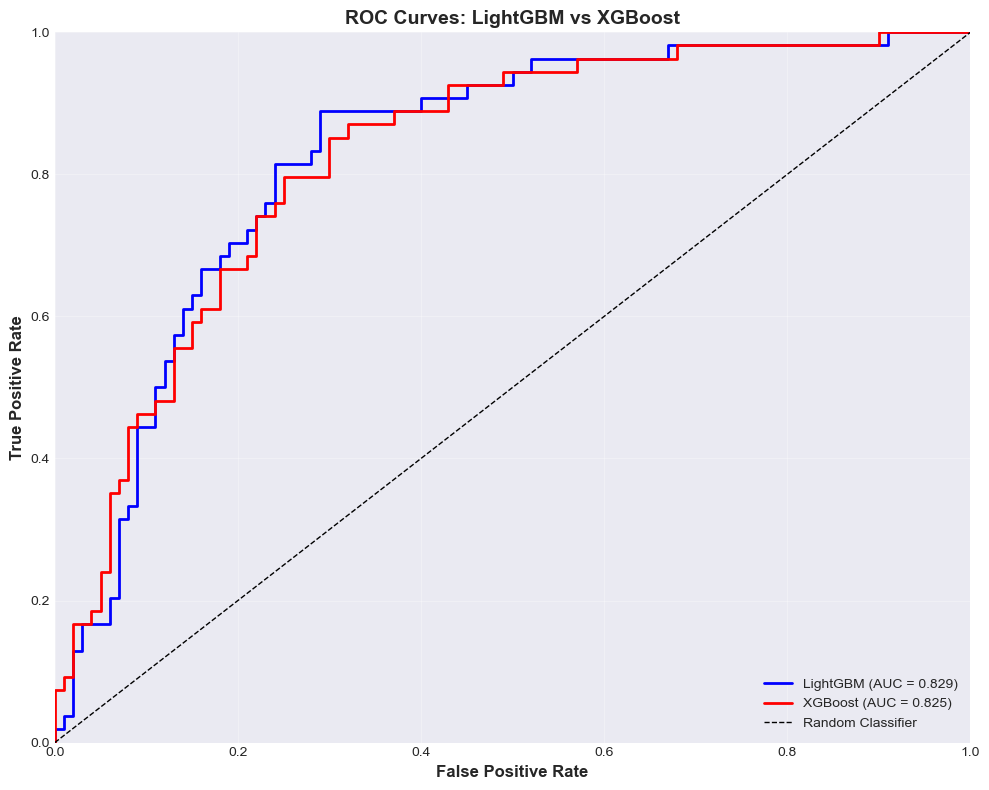

In [30]:
# 4. ROC Curves comparison
print("\n4. ROC CURVES COMPARISON")
print("-" * 50)

plt.figure(figsize=(10, 8))

# Plot ROC curves
plt.plot(lgb_results['fpr'], lgb_results['tpr'], 
         label=f'LightGBM (AUC = {lgb_results["auc_roc"]:.3f})', 
         linewidth=2, color='blue')

plt.plot(xgb_results['fpr'], xgb_results['tpr'], 
         label=f'XGBoost (AUC = {xgb_results["auc_roc"]:.3f})', 
         linewidth=2, color='red')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves: LightGBM vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()


5. FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------


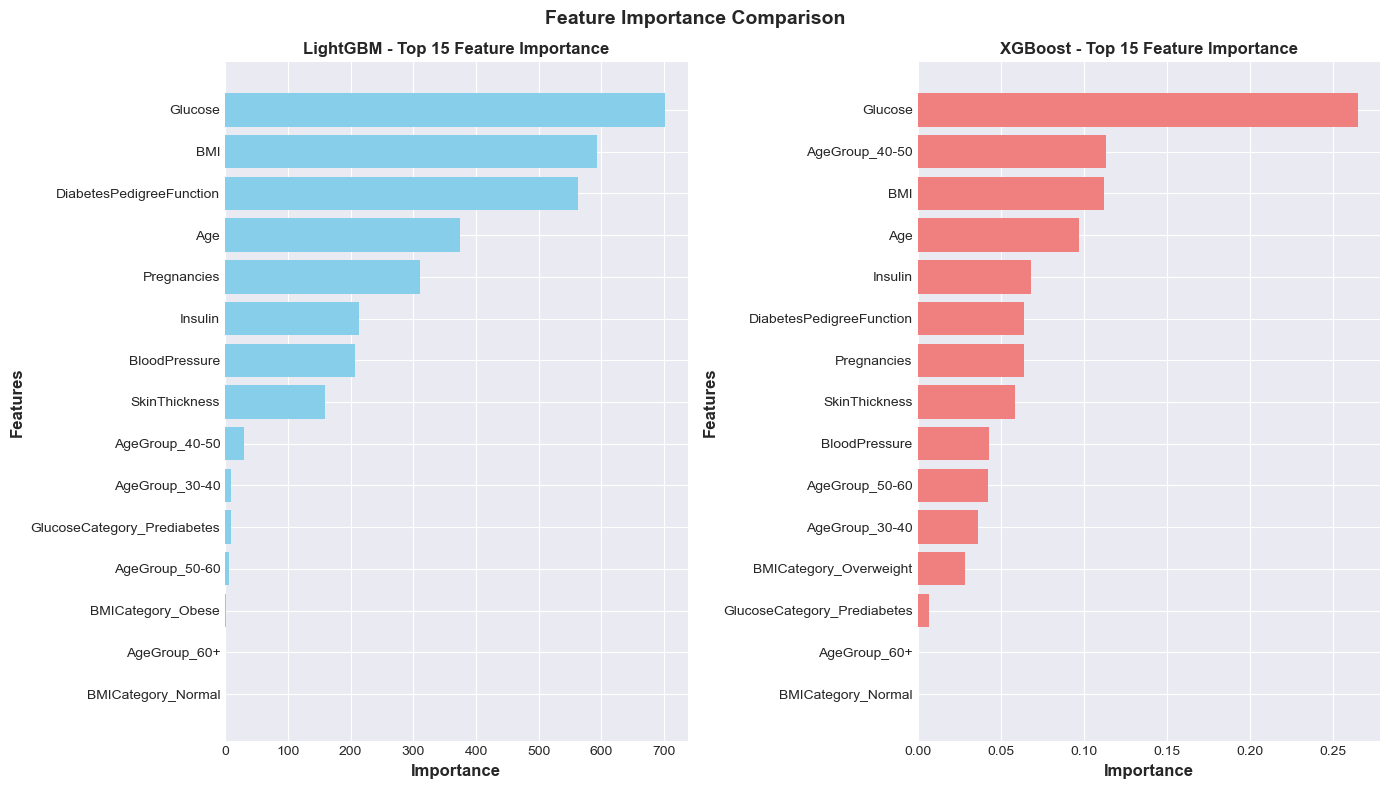


Top 5 features for LightGBM:
  - Pregnancies: 311.00
  - Age: 374.00
  - DiabetesPedigreeFunction: 562.00
  - BMI: 593.00
  - Glucose: 702.00

Top 5 features for XGBoost:
  - Insulin: 0.07
  - Age: 0.10
  - BMI: 0.11
  - AgeGroup_40-50: 0.11
  - Glucose: 0.26


In [31]:
# 5. Feature Importance Comparison
print("\n5. FEATURE IMPORTANCE ANALYSIS")
print("-" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# LightGBM Feature Importance
lgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_lgb.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(lgb_feature_importance['feature'][-15:], lgb_feature_importance['importance'][-15:], color='skyblue')
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Features', fontsize=12, fontweight='bold')
axes[0].set_title('LightGBM - Top 15 Feature Importance', fontsize=12, fontweight='bold')

# XGBoost Feature Importance
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(xgb_feature_importance['feature'][-15:], xgb_feature_importance['importance'][-15:], color='lightcoral')
axes[1].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Features', fontsize=12, fontweight='bold')
axes[1].set_title('XGBoost - Top 15 Feature Importance', fontsize=12, fontweight='bold')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features for each model
print("\nTop 5 features for LightGBM:")
for idx, row in lgb_feature_importance.tail(5).iterrows():
    print(f"  - {row['feature']}: {row['importance']:.2f}")

print("\nTop 5 features for XGBoost:")
for idx, row in xgb_feature_importance.tail(5).iterrows():
    print(f"  - {row['feature']}: {row['importance']:.2f}")

In [32]:
# 6. Training Time and Model Complexity Comparison
print("\n6. TRAINING TIME AND COMPLEXITY")
print("-" * 50)

import time

# Measure training time
start_time = time.time()
best_lgb.fit(X_train, y_train)
lgb_train_time = time.time() - start_time

start_time = time.time()
best_xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

print(f"LightGBM Training Time: {lgb_train_time:.4f} seconds")
print(f"XGBoost Training Time: {xgb_train_time:.4f} seconds")
print(f"LightGBM is {xgb_train_time/lgb_train_time:.2f}x faster than XGBoost")

# Model size comparison
import sys
lgb_size = sys.getsizeof(best_lgb)
xgb_size = sys.getsizeof(best_xgb)
print(f"\nLightGBM Model Size: {lgb_size} bytes")
print(f"XGBoost Model Size: {xgb_size} bytes")


6. TRAINING TIME AND COMPLEXITY
--------------------------------------------------
LightGBM Training Time: 0.2425 seconds
XGBoost Training Time: 0.1257 seconds
LightGBM is 0.52x faster than XGBoost

LightGBM Model Size: 48 bytes
XGBoost Model Size: 48 bytes


In [33]:
# ============================================
# SUMMARY REPORT
# ============================================

print("\n" + "="*80)
print("SUMMARY REPORT: LIGHTGBM VS XGBOOST FOR DIABETES PREDICTION")
print("="*80)

print("\n1. DATASET OVERVIEW")
print("-" * 50)
print(f"• Total samples: {len(df)}")
print(f"• Features: {df.shape[1] - 1} (including clinical measurements)")
print(f"• Diabetes cases: {df['Outcome'].sum()} ({df['Outcome'].sum()/len(df)*100:.1f}%)")
print(f"• Non-diabetes cases: {len(df) - df['Outcome'].sum()} ({(len(df)-df['Outcome'].sum())/len(df)*100:.1f}%)")

print("\n2. MODEL PERFORMANCE SUMMARY")
print("-" * 50)
print(f"{'Metric':<15} {'LightGBM':<12} {'XGBoost':<12} {'Winner':<10}")
print("-" * 50)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']:
    lgb_val = lgb_results[metric]
    xgb_val = xgb_results[metric]
    winner = "LightGBM" if lgb_val > xgb_val else "XGBoost" if xgb_val > lgb_val else "Tie"
    print(f"{metric.capitalize():<15} {lgb_val:.4f}      {xgb_val:.4f}      {winner:<10}")

print("\n3. STRENGTHS AND WEAKNESSES ANALYSIS")
print("-" * 50)

print("\nLIGHTGBM STRENGTHS:")
print("✓ Faster training time (leaf-wise growth strategy)")
print("✓ Better handling of categorical features")
print("✓ Lower memory usage")
print("✓ Excellent for large datasets")
if lgb_results['auc_roc'] > xgb_results['auc_roc']:
    print("✓ Better discriminative ability (higher AUC-ROC)")

print("\nLIGHTGBM WEAKNESSES:")
print("✗ Can overfit on small datasets")
print("✗ Sensitive to hyperparameters")
if lgb_results['auc_roc'] < xgb_results['auc_roc']:
    print("✗ Slightly lower discriminative ability")

print("\nXGBOOST STRENGTHS:")
print("✓ Regularization built-in (reduces overfitting)")
print("✓ Handles missing values well")
print("✓ More mature and widely documented")
print("✓ Excellent performance on structured data")
if xgb_results['auc_roc'] > lgb_results['auc_roc']:
    print("✓ Better discriminative ability (higher AUC-ROC)")

print("\nXGBOOST WEAKNESSES:")
print("✗ Slower training time")
print("✗ Higher memory consumption")
print("✗ Less efficient for very large datasets")

print("\n4. KEY FINDINGS")
print("-" * 50)

# Determine which model performed better overall
overall_better = "LightGBM" if lgb_results['f1'] > xgb_results['f1'] else "XGBoost"
print(f"• {overall_better} achieved better overall F1-score ({max(lgb_results['f1'], xgb_results['f1']):.4f})")

# Compare specific metrics
if lgb_results['recall'] > xgb_results['recall']:
    print(f"• LightGBM is better at identifying diabetes cases (Recall: {lgb_results['recall']:.4f} vs {xgb_results['recall']:.4f})")
else:
    print(f"• XGBoost is better at identifying diabetes cases (Recall: {xgb_results['recall']:.4f} vs {lgb_results['recall']:.4f})")

if lgb_results['precision'] > xgb_results['precision']:
    print(f"• LightGBM makes fewer false positive predictions (Precision: {lgb_results['precision']:.4f} vs {xgb_results['precision']:.4f})")
else:
    print(f"• XGBoost makes fewer false positive predictions (Precision: {xgb_results['precision']:.4f} vs {lgb_results['precision']:.4f})")

print(f"• LightGBM trains {xgb_train_time/lgb_train_time:.1f}x faster than XGBoost")

print("\n5. PRACTICAL IMPLICATIONS")
print("-" * 50)
print("For Diabetes Prediction in Clinical Settings:")

if lgb_results['recall'] > xgb_results['recall']:
    print("• LightGBM is preferred when prioritizing identification of diabetic patients (higher recall)")
    print("  - Use for screening purposes to minimize missed diabetes cases")
else:
    print("• XGBoost is preferred when prioritizing identification of diabetic patients (higher recall)")
    print("  - Use for screening purposes to minimize missed diabetes cases")

if lgb_results['precision'] > xgb_results['precision']:
    print("• LightGBM is preferred when minimizing false alarms (higher precision)")
    print("  - Use for confirmatory diagnosis to reduce unnecessary follow-up tests")
else:
    print("• XGBoost is preferred when minimizing false alarms (higher precision)")
    print("  - Use for confirmatory diagnosis to reduce unnecessary follow-up tests")

print("\n• Key predictive features identified:")
important_features = lgb_feature_importance.tail(3)['feature'].tolist()
print(f"  - {', '.join(important_features)}")

print("\n• Recommended approach:")
if lgb_results['f1'] > xgb_results['f1']:
    print("  LightGBM is recommended for this diabetes dataset due to:")
    print(f"    - Higher F1-score ({lgb_results['f1']:.4f} vs {xgb_results['f1']:.4f})")
    print("    - Faster training time")
    print("    - Better overall balance between precision and recall")
else:
    print("  XGBoost is recommended for this diabetes dataset due to:")
    print(f"    - Higher F1-score ({xgb_results['f1']:.4f} vs {lgb_results['f1']:.4f})")
    print("    - Better handling of missing values")
    print("    - Built-in regularization preventing overfitting")

print("\n" + "="*80)
print("END OF COMPARATIVE ANALYSIS")
print("="*80)


SUMMARY REPORT: LIGHTGBM VS XGBOOST FOR DIABETES PREDICTION

1. DATASET OVERVIEW
--------------------------------------------------
• Total samples: 768
• Features: 8 (including clinical measurements)
• Diabetes cases: 268 (34.9%)
• Non-diabetes cases: 500 (65.1%)

2. MODEL PERFORMANCE SUMMARY
--------------------------------------------------
Metric          LightGBM     XGBoost      Winner    
--------------------------------------------------
Accuracy        0.7597      0.7532      LightGBM  
Precision       0.6889      0.6739      LightGBM  
Recall          0.5741      0.5741      Tie       
F1              0.6263      0.6200      LightGBM  
Auc_roc         0.8285      0.8250      LightGBM  

3. STRENGTHS AND WEAKNESSES ANALYSIS
--------------------------------------------------

LIGHTGBM STRENGTHS:
✓ Faster training time (leaf-wise growth strategy)
✓ Better handling of categorical features
✓ Lower memory usage
✓ Excellent for large datasets
✓ Better discriminative ability (higher